In [46]:
import numpy as np
import pandas as pd
import os, subprocess, vcf, itertools, time


def VAF_CALC ( d ):
    if d.data.AF == None:
        return 0
    else:
        if d.data.GT in [ "0/1", "0|1" ]:
            return d.data.AD [1] / d.data.DP
        elif d.data.GT in [ "1/0", "1|0" ]:
            return d.data.AD [0] / d.data.DP
        else:
            return 0

def MAKE_METEL_INPUT ( row_i, col_i, INPUT_VCF,METEL_INPUT_TSV):
    output_file = open ( METEL_INPUT_TSV, "w")

    vcf_reader = vcf.Reader( open ( INPUT_VCF, "r") )
    for record in vcf_reader: 
        vaf_row = VAF_CALC ( record.samples [row_i] )
        vaf_col = VAF_CALC  ( record.samples [col_i] ) 
        if (vaf_row == 0) & (vaf_col == 0):
            continue

        if record.CHROM == "chr22" and 29603556 <= record.POS <= 29698600:
            print ( "{}\tNF2\t.\t.\t{}\t{}".format ( Sample_ID, vaf_row, vaf_col), file = output_file )
        elif record.CHROM == "chr9" and record.POS == 107487067:
            print ( "{}\tKLF4\t.\t.\t{}\t{}".format ( Sample_ID, vaf_row, vaf_col), file = output_file )
        elif record.CHROM == "chr14" and record.POS == 107480214:
            print ( "{}\tAKT1\t.\t.\t{}\t{}".format ( Sample_ID, vaf_row, vaf_col), file = output_file )
        elif record.CHROM == "chr16" and 2175608 <= record.POS <= 2176200:
            print ( "{}\tTRAF7\t.\t.\t{}\t{}".format ( Sample_ID, vaf_row, vaf_col), file = output_file )
        else:
            print ( "{}\t{}\t.\t.\t{}\t{}".format ( Sample_ID, record.CHROM + ":" + str (record.POS), vaf_row, vaf_col), file = output_file )

    output_file.close()


##############################################################################################################

INPUT_DIR="/data/project/Meningioma/04.mutect/07.2D_merged/02.BCFTOOLS_MERGE_VCF"
sample_list = [ "190426_PFT", "190426_PCT", "190426_PP", "190426_PT", "190426_FFT",
    "230802_2", "230419", "241023",  "221102", "240403_3", "240412_2",  "230127", "190524",  
    "240320", "231025", "230323_2", "230323_11", "230920", "230822", 
    "230405_2", "230303_1", "231006", "221202", "231006",  # Shareed mosaicism 
    "220930_1", "221026",  "240110", "241127", "241016", "250212"       # PC 6개
]


df_acc = pd.DataFrame (  columns = [ "Sample_ID",  "contam", "samplenames[row_i]", "samplenames[col_i]", "Classification_Score(s)", "Diagnosis_Result"] )

for Sample_ID in sample_list:

    vcf_reader = vcf.Reader( open ( INPUT_DIR + "/" + Sample_ID + ".BCFTOOLS_MERGE.vcf", "r") )
    samplenames = vcf_reader.samples
    #print (samplenames)
    os.makedirs ( "/data/project/Meningioma/04.mutect/11.MeTel/" + Sample_ID + "/01.Input" , exist_ok = True)
    os.makedirs ( "/data/project/Meningioma/04.mutect/11.MeTel/" + Sample_ID + "/02.Output" , exist_ok = True)


    i_li = []
    for i, samplename in enumerate (samplenames):
        if  ("Blood" in samplename) :
            continue
        i_li.append ( i )

    # Classification score에 대해 df 를 선언
    for i1, row_i in enumerate ( i_li ) :
        if "Tumor" in samplenames[row_i] :
            for i2, col_i in enumerate ( i_li):
                if row_i == col_i:
                    continue
                if any( x in samplenames[col_i] for x in ["Ventricle", "Cortex", "Falx_2"]) :
                    continue
                #print ( samplenames[row_i], samplenames [col_i]  )

                METEL_INPUT_TSV = "/data/project/Meningioma/04.mutect/11.MeTel/" + str (Sample_ID)+ "/01.Input/" + samplenames[row_i] + "_and_" + samplenames[col_i] + ".tsv"
                MAKE_METEL_INPUT ( row_i, col_i , INPUT_DIR + "/" + Sample_ID + ".BCFTOOLS_MERGE.vcf", METEL_INPUT_TSV)
                METEL_OUTPUT_TSV = "/data/project/Meningioma/04.mutect/11.MeTel/" + str ( Sample_ID ) + "/02.Output/" + samplenames[row_i] + "_and_" + samplenames[col_i] + ".tsv"
                os.system  ( "python3 MetelNF2.py {} {}".format ( METEL_INPUT_TSV, METEL_OUTPUT_TSV ))
                print (  "python3 MetelNF2.py {} {}".format ( METEL_INPUT_TSV, METEL_OUTPUT_TSV ) )
                
                time.sleep ( 1 )
                output_df = pd.read_csv ( METEL_OUTPUT_TSV, sep = "\t")
                print ( "\t{} & {} -> {} ( {} )".format ( samplenames[row_i], samplenames [col_i] ,  np.round ( output_df ["Classification_Score(s)"][0], 1 ) , output_df ["Diagnosis_Result"][0] ) )

                contam = "Tumor infiltrated" if any(pc in samplenames[row_i] for pc in ["220930_1", "221026", "240110", "241127", "241016", "250212"]) else "Meningeal mosaicism"
                df_acc.loc [ len(df_acc) ] = [ Sample_ID, contam, samplenames[row_i], samplenames[col_i], output_df ["Classification_Score(s)"][0], output_df ["Diagnosis_Result"][0] ]

    #df = df.apply(lambda x: np.power(10, x)).round (2)

python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/190426_PFT/01.Input/190426_PFT_Tumor_and_190426_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/190426_PFT/02.Output/190426_PFT_Tumor_and_190426_Dura.tsv
	190426_PFT_Tumor & 190426_Dura -> -2.6 ( MPLC )
python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/190426_PCT/01.Input/190426_PCT_Tumor_and_190426_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/190426_PCT/02.Output/190426_PCT_Tumor_and_190426_Dura.tsv
	190426_PCT_Tumor & 190426_Dura -> -2.6 ( MPLC )
python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/190426_PP/01.Input/190426_PP_Tumor_and_190426_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/190426_PP/02.Output/190426_PP_Tumor_and_190426_Dura.tsv
	190426_PP_Tumor & 190426_Dura -> -3.5 ( MPLC )
python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/190426_PT/01.Input/190426_PT_Tumor_and_190426_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/190426_PT/02.Output/190426

In [47]:
df_acc

,Sample_ID,contam,samplenames[row_i],samplenames[col_i],Classification_Score(s),Diagnosis_Result
0,190426_PFT,Meningeal mosaicism,190426_PFT_Tumor,190426_Dura,-2.596010,MPLC
1,190426_PCT,Meningeal mosaicism,190426_PCT_Tumor,190426_Dura,-2.596442,MPLC
2,190426_PP,Meningeal mosaicism,190426_PP_Tumor,190426_Dura,-3.496496,MPLC
3,190426_PT,Meningeal mosaicism,190426_PT_Tumor,190426_Dura,-2.602031,MPLC
4,190426_FFT,Meningeal mosaicism,190426_FFT_Tumor,190426_Dura,-2.602031,MPLC
5,230802_2,Meningeal mosaicism,230802_2_Tumor,230802_2_Dura,-2.404385,MPLC
6,230419,Meningeal mosaicism,230419_Tumor,230419_Dura,-2.158928,MPLC
7,241023,Meningeal mosaicism,241023_Tumor,241023_Dura,-28.238778,MPLC
8,221102,Meningeal mosaicism,221102_Tumor,221102_Dura,-6.505715,MPLC
9,240403_3,Meningeal mosaicism,240403_3_Tumor,240403_3_Dura,-3.325494,MPLC





Classification_Score(s)	-> Mann-Whitney U test statistic: 16.0	P-value : 0.0005
                       mean     std  count
contam                                    
Meningeal mosaicism   1.403  11.432     24
Tumor infiltrated    40.354  34.430      8


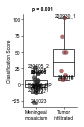

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import matplotlib as mpl
import glob

# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/ARIAL*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'

def DRAW_DF_VIS3_boxplot ( df_inside, x = "contam", y = "meanVAF_dura_shared",  xlabel = "", ylabel = "meanVAF of shared mutations", ylim = 1.051, hue = "contam", palette =  ["blue", "red" ], OUTPUT_PATH = "/data/project/Meningioma/31.Clonality/TP_TN_boxplot_1.pdf" ):
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = kwargs["figsize"])
    fig.subplots_adjust ( wspace = 0.3, bottom = 0.12, top = 0.93, left = 0.25, right = 0.94 )

    df_inside = df_inside[(df_inside[x].isna() == False) & (df_inside[y].isna() == False)]
    df_inside [y] = df_inside [y] .astype (float)
    
    # boxplot 그리기
    box = sns.boxplot ( data=df_inside, x=x, y=y, hue=hue, palette=palette, linewidth=kwargs["linewidth_box"], dodge=False,  showfliers=True, flierprops=dict(marker=kwargs["flier_marker"], markersize=kwargs["fliersize"], alpha=kwargs["flier_alpha"], markeredgecolor=kwargs["markeredgecolor"] ) , ax=ax )
    for i, patch in enumerate(box.patches):
        patch.set_facecolor('none')

    # boxplot 위에 scatter plot(=strip plot) 추가
    sns.stripplot (  data=df_inside,  x=x, y=y, hue=hue,  palette=palette,  dodge=False, jitter=True,  size = kwargs.get("strip_size", 4),   marker=kwargs.get("strip_marker", "o"), linewidth=0.3, edgecolor="gray",  alpha=0.7,    ax=ax  )
    
    # outlier에 Sample_ID 텍스트 추가
    for i, group in enumerate(df_inside[x].unique()):
        group_data = df_inside[df_inside[x] == group]    
        # IQR 계산하여 outlier 찾기
        Q1 = group_data[y].quantile(0.25)
        Q3 = group_data[y].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1
        upper_bound = Q3 + 0.5 * IQR
        
        # outlier 찾기
        outliers = group_data[(group_data[y] < lower_bound) | (group_data[y] > upper_bound)]
        # outlier에 Sample_ID 텍스트 추가
        for idx, row in outliers.iterrows():
            ax.text(i + 0.1, row[y], row['Sample_ID'],  fontsize = kwargs["label_fontsize"], ha='center', va='bottom')



    
    # Mann-Whitney U test
    stat, p = mannwhitneyu(
        df_inside[df_inside["contam"] == "Meningeal mosaicism"][y ].dropna(),
        df_inside[df_inside["contam"] == "Tumor infiltrated"][y ].dropna(),
        alternative = 'two-sided'
    )
    print("\n\n\n{}\t-> Mann-Whitney U test statistic: {}\tP-value : {}".format ( y , round(stat, 1), round(p, 4)) )
    print ( df_inside.groupby("contam")[ y ].agg(["mean", "std", "count"]).round(3) )


    # p-value를 상단 가운데에 표시
    fig.text(0.5, 0.95, f'p = {round(p, 3)}', ha='center', va='bottom', fontsize=kwargs["label_fontsize"], fontweight='bold', transform=fig.transFigure)

    # x축 레이블에서 공백을 줄바꿈으로 치환
    ax.set_xticklabels ( [label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()] )

    ax.set_xlabel ( xlabel, fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.set_ylabel ( ylabel, fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.tick_params ( axis = 'both', labelsize = kwargs["tick_labelsize"], pad = kwargs["tick_pad"], length = kwargs["tick_length"], width = kwargs["tick_width"] )

    for ax_individual in [ ax ]:
        for axis in ['left','bottom']:
            ax_individual.spines[axis].set_linewidth( 0.5 )
        for axis in ['right','top']:
            ax_individual.spines[axis].set_linewidth( 0 )
        
    ax.get_legend().remove()

    fig.savefig ( OUTPUT_PATH, dpi = 300)


    ############################################################

kwargs = {}
kwargs.update({"figsize": (1.1, 1.6), "scatter_size": 50,  "label_fontsize": 6, "labelpad": 0, "tick_labelsize": 6, "tick_pad": 0, "tick_length": 2, "tick_width": 0.5, "linewidth": 0.5, "linewidth_box": 0.75, "palette" : [  "#333333", "#A23636" ], "alpha" : 0.7, "trendline" : False, 
                        "xticks" : np.round ( np.arange (0, 30.1, 10)  , 2),   "yticks" : np.round ( np.arange (0, 0.151, 0.05)  , 2), "label_text" : True,
                         "xlabel" : "number of shared mutations", "ylabel" : "meanVAF of shared mutations", "OUTPUT_PATH": "/data/project/Meningioma/31.Clonality/Boxplot_MeTel_pairwise_score.jpg"})
kwargs.update({ "fliersize" : 3, "flier_marker" : 'o', "flier_alpha" : 0.6, "markeredgecolor" : 'none' } )

DRAW_DF_VIS3_boxplot ( df_acc, x = "contam", y = "Classification_Score(s)",  xlabel = "", ylabel = "Classification Score", ylim = 0.151,  hue = "contam",  palette = kwargs["palette"],  OUTPUT_PATH = kwargs["OUTPUT_PATH"] )




In [45]:
!python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/190426_PCT/01.Input/190426_PCT_Tumor_and_190426_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/190426_PCT/02.Output/190426_PCT_Tumor_and_190426_Dura.tsv

chr1:17425675	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.009	ab_list = 0	ba_list = -0.008
chr1:151048132	mutation frequency = 1e-06	avaf = 0.045	bvaf = 0.0	ab_list = -0.041	ba_list = 0
chr1:235980591	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.009	ab_list = 0	ba_list = -0.008
chr2:26774230	mutation frequency = 1e-06	avaf = 0.037	bvaf = 0.0	ab_list = -0.033	ba_list = 0
chr2:28298497	mutation frequency = 0.6	avaf = 0.152	bvaf = 0.004	ab_list = 0.08	ba_list = 0.002
chr2:100975407	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.069	ab_list = 0	ba_list = -0.065
chr6:148533864	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.043	ab_list = 0	ba_list = -0.039
chr7:100064397	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.014	ab_list = 0	ba_list = -0.013
chr7:138911263	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.011	ab_list = 0	ba_list = -0.009
chr8:99507844	mutation frequency = 1e-06	avaf = 0.091	bvaf = 0.0	ab_list = -0.088	ba_list = 0
chr9:76023833	mutation frequency = 1e-06	avaf = 0.10

In [6]:
!python3 MetelNF2.py /data/project/Meningioma/04.mutect/11.MeTel/240412_2/01.Input/240412_2_Tumor_and_240412_2_Dura.tsv /data/project/Meningioma/04.mutect/11.MeTel/240412_2/02.Output/240412_2_Tumor_and_240412_2_Dura.tsv

chr1:119894689	mutation frequency = 1e-06	avaf = 0.056	bvaf = 0.0	ab_list = -0.051	ba_list = 0
chr1:179509313	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.018	ab_list = 0	ba_list = -0.016
chr2:218434597	mutation frequency = 1e-06	avaf = 0.107	bvaf = 0.0	ab_list = -0.104	ba_list = 0
chr5:118987997	mutation frequency = 1e-06	avaf = 0.431	bvaf = 0.0	ab_list = -0.862	ba_list = 0
chr6:7269224	mutation frequency = 1e-06	avaf = 0.068	bvaf = 0.0	ab_list = -0.064	ba_list = 0
chr6:73353797	mutation frequency = 1e-06	avaf = 0.338	bvaf = 0.004	ab_list = 5.83	ba_list = 3.867
chr8:66850840	mutation frequency = 1e-06	avaf = 0.378	bvaf = 0.0	ab_list = -0.614	ba_list = 0
chr9:130402780	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.014	ab_list = 0	ba_list = -0.012
chr10:19128251	mutation frequency = 1e-06	avaf = 0.25	bvaf = 0.0	ab_list = -0.301	ba_list = 0
chr10:98397434	mutation frequency = 1e-06	avaf = 0.0	bvaf = 0.014	ab_list = 0	ba_list = -0.013
chr11:124886557	mutation frequency = 1e-06	avaf = 0

--- 

### Heatmap visualization

In [3]:
import seaborn as sns
import matplotlib as mpl
import math, glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/arial*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'


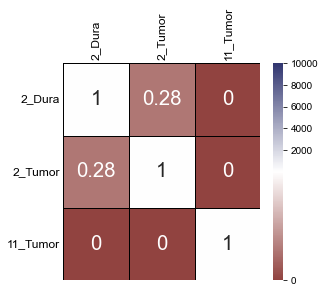

In [ ]:
fig, ax = plt.subplots ( nrows = 1, ncols = 1, figsize =(4.5, 4.5))

colors = [ "#914340", "white", "#313670"]
positions = [0, 0.5, 1]  # Define the positions for each color
cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))

cmap = LinearSegmentedColormap.from_list("custom_red_blue", colors, N=256)
# 2. 0~1은 빨간색 계열, 1~10000은 파란색 계열로 지정
norm = TwoSlopeNorm(vmin=0, vcenter=1, vmax=10000)



fig.subplots_adjust ( wspace = 0.4, bottom = 0.03, top = 0.7, left = 0.22, right = 0.98)
fig.set_facecolor('white')

sns.heatmap ( df , cmap = cmap, norm = norm, linewidths = 0.5, linecolor = "black", annot = df, annot_kws={"size": 35 / np.sqrt(len( df))} )   # fmt=".2f", 
#fig.suptitle ( title, fontsize = 12, fontweight = "bold", ha = "left", x = 0 )
ax.set_xticklabels( [ i.get_text().replace( Sample_ID + "_" , "" ) for i in ax.get_xticklabels()],  ha = 'center', rotation = 90 )
ax.tick_params(axis = 'x',  pad = -0.5)
ax.set_yticklabels( [ i.get_text().replace( Sample_ID + "_" , "" ) for i in ax.get_yticklabels()], va = 'center' )
ax.tick_params(axis = 'y', pad = -0.5 )

plt.tick_params(axis='both', which='major', labelsize = 12, left = False, labelbottom = False, bottom=False, top = False, labeltop=True)


fig.savefig ( "/data/project/Meningioma/04.mutect/11.MeTel/" + str ( Sample_ID ) + "/02.Output/heatmap.pdf", dpi = 300)
fig.savefig ( "/data/project/Meningioma/script/03.Variant_calling_Annotation/MeTel.heatmap.pdf", dpi = 300)